In [1]:
import re
import random
import time
from collections import Counter
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)

SEED = 10

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
# load the AG News dataset
dataset = load_dataset("sh0416/ag_news")

df_train_full = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])

# make the train/dev split the same way as A1 and A2
df_train, df_dev = train_test_split(
    df_train_full, test_size=0.1, random_state=SEED,
    stratify=df_train_full["label"],
)
df_train = df_train.reset_index(drop=True)
df_dev = df_dev.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# use the same smaller subset as A2 so training stays manageable
df_train = df_train.sample(n=5000, random_state=SEED).reset_index(drop=True)
df_dev = df_dev.sample(n=1000, random_state=SEED).reset_index(drop=True)
df_test = df_test.sample(n=1000, random_state=SEED).reset_index(drop=True)

# join title and description into one text field
for df in [df_train, df_dev, df_test]:
    df["text"] = df["title"] + " " + df["description"]

AG_LABELS = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
NUM_CLASSES = 4

print(f"Train: {len(df_train):,}  Dev: {len(df_dev):,}  Test: {len(df_test):,}")
print(f"Label distribution (train):\n{df_train['label'].value_counts().sort_index()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/33.7M [00:00<?, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train: 5,000  Dev: 1,000  Test: 1,000
Label distribution (train):
label
1    1270
2    1214
3    1240
4    1276
Name: count, dtype: int64


In [3]:
# tokenizer and vocab for the CNN part
TOKEN_RE = re.compile(r"[A-Za-z0-9']+")

def tokenize(text: str):
    return TOKEN_RE.findall(text.lower())

PAD, UNK = "<pad>", "<unk>"

def build_vocab(texts, min_freq=2, max_size=30000):
    counter = Counter()
    for t in texts:
        counter.update(tokenize(t))
    vocab = {PAD: 0, UNK: 1}
    for word, freq in counter.most_common():
        if freq < min_freq or len(vocab) >= max_size:
            break
        vocab[word] = len(vocab)
    return vocab

def numericalize(tokens, vocab):
    return [vocab.get(t, vocab[UNK]) for t in tokens]

vocab = build_vocab(df_train["text"])
VOCAB_SZ = len(vocab)
PAD_IDX = vocab[PAD]
print(f"Vocabulary size: {VOCAB_SZ:,}")

Vocabulary size: 10,652


In [4]:
# dataset classes and dataloaders
MAX_LEN = 128
BATCH_SIZE = 64

@dataclass
class Batch:
    x: torch.Tensor
    lengths: torch.Tensor
    y: torch.Tensor

class TextDataset(Dataset):
    def __init__(self, df, vocab, max_len=MAX_LEN):
        self.df, self.vocab, self.max_len = df, vocab, max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        ids = numericalize(tokenize(str(row["text"])), self.vocab)[:self.max_len]
        return ids or [self.vocab[UNK]], int(row["label"]) - 1

def collate(batch):
    lengths = torch.tensor([len(x) for x, _ in batch], dtype=torch.long)
    x = torch.full((len(batch), int(lengths.max())), PAD_IDX, dtype=torch.long)
    y = torch.tensor([lbl for _, lbl in batch], dtype=torch.long)
    for i, (ids, _) in enumerate(batch):
        x[i, :len(ids)] = torch.tensor(ids, dtype=torch.long)
    return Batch(x=x, lengths=lengths, y=y)

train_loader = DataLoader(TextDataset(df_train, vocab), batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate)
dev_loader = DataLoader(TextDataset(df_dev, vocab), batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=collate)
test_loader = DataLoader(TextDataset(df_test, vocab), batch_size=BATCH_SIZE,
                         shuffle=False, collate_fn=collate)

In [5]:
# CNN model from Assignment 2
EMBED_DIM = 128
NUM_FILTERS = 128
KERNEL_SIZES = (3, 4, 5)
DROPOUT = 0.3

class CNNTextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, num_filters=NUM_FILTERS,
                 kernel_sizes=KERNEL_SIZES, dropout=DROPOUT, pad_idx=PAD_IDX,
                 num_classes=NUM_CLASSES):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.emb_drop = nn.Dropout(dropout)
        self.convs = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes])
        self.rep_drop = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x, lengths):
        emb = self.emb_drop(self.embedding(x)).transpose(1, 2)
        pooled = [torch.relu(conv(emb)).max(dim=2).values for conv in self.convs]
        return self.fc(self.rep_drop(torch.cat(pooled, dim=1)))

In [6]:
# helper functions for training
LR = 0.001
MAX_EPOCHS = 20
PATIENCE = 5

def evaluate_cnn(model, loader):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    all_y, all_pred = [], []
    total_loss, n = 0, 0
    with torch.no_grad():
        for batch in loader:
            x, lengths, y = batch.x.to(device), batch.lengths.to(device), batch.y.to(device)
            logits = model(x, lengths)
            total_loss += loss_fn(logits, y).item() * y.size(0)
            all_y.append(y.cpu().numpy())
            all_pred.append(logits.argmax(1).cpu().numpy())
            n += y.size(0)
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    return {
        "loss": total_loss / max(n, 1),
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true, "y_pred": y_pred,
    }

def fit_cnn(model, train_loader, val_loader, lr=LR, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)
    best_val, best_state, bad_epochs = float("inf"), None, 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        t0 = time.perf_counter()
        total_loss, n, correct = 0, 0, 0
        for batch in train_loader:
            x, lengths, y = batch.x.to(device), batch.lengths.to(device), batch.y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x, lengths)
            loss = loss_fn(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * y.size(0)
            n += y.size(0)
            correct += (logits.argmax(1) == y).sum().item()

        val = evaluate_cnn(model, val_loader)
        scheduler.step(val["loss"])
        history.append(dict(epoch=epoch,
                            train_loss=total_loss / max(n, 1),
                            train_acc=correct / max(n, 1),
                            val_loss=val["loss"], val_acc=val["acc"],
                            val_f1=val["f1"],
                            time_s=time.perf_counter() - t0))
        r = history[-1]
        print(f"[{epoch:02d}] train_loss={r['train_loss']:.4f} acc={r['train_acc']:.4f} | "
              f"val_loss={r['val_loss']:.4f} acc={r['val_acc']:.4f} f1={r['val_f1']:.4f} | "
              f"{r['time_s']:.1f}s")

        if val["loss"] < best_val - 1e-6:
            best_val, bad_epochs = val["loss"], 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return history

In [ ]:
# train the CNN on the reused split
set_seed()
cnn_model = CNNTextClassifier(VOCAB_SZ).to(device)

print("Training CNN on the reused Assignment 2 split...")
hist_cnn = fit_cnn(cnn_model, train_loader, dev_loader)

val_cnn = evaluate_cnn(cnn_model, dev_loader)
test_cnn = evaluate_cnn(cnn_model, test_loader)

print(f"\nCNN Results:")
print(f"  Dev:  Acc={val_cnn['acc']:.4f}  Macro-F1={val_cnn['f1']:.4f}")
print(f"  Test: Acc={test_cnn['acc']:.4f}  Macro-F1={test_cnn['f1']:.4f}")

Training CNN (best A2 model) on full dataset...
[01] train_loss=1.3746 acc=0.3568 | val_loss=1.0491 acc=0.6040 f1=0.5864 | 2.5s
[02] train_loss=1.0226 acc=0.5852 | val_loss=0.9042 acc=0.6700 f1=0.6572 | 0.9s
[03] train_loss=0.8351 acc=0.6740 | val_loss=0.6990 acc=0.7620 f1=0.7604 | 0.9s
[04] train_loss=0.6883 acc=0.7346 | val_loss=0.6392 acc=0.7690 f1=0.7662 | 1.1s
[05] train_loss=0.5733 acc=0.7832 | val_loss=0.5559 acc=0.8030 f1=0.8007 | 1.2s
[06] train_loss=0.4821 acc=0.8238 | val_loss=0.5314 acc=0.8000 f1=0.7961 | 1.0s
[07] train_loss=0.4169 acc=0.8504 | val_loss=0.5319 acc=0.8010 f1=0.7972 | 0.9s
[08] train_loss=0.3690 acc=0.8656 | val_loss=0.4765 acc=0.8290 f1=0.8273 | 0.8s
[09] train_loss=0.3192 acc=0.8888 | val_loss=0.4854 acc=0.8230 f1=0.8202 | 0.8s
[10] train_loss=0.2692 acc=0.8970 | val_loss=0.4752 acc=0.8270 f1=0.8251 | 0.9s
[11] train_loss=0.2363 acc=0.9162 | val_loss=0.4814 acc=0.8280 f1=0.8256 | 0.9s
[12] train_loss=0.2098 acc=0.9280 | val_loss=0.4708 acc=0.8340 f1=0.8323

In [ ]:
# DistilBERT setup
TRANSFORMER_NAME = "distilbert-base-uncased"
TRANSFORMER_MAX_LEN = 128
TRANSFORMER_BATCH_SIZE = 32
TRANSFORMER_LR = 2e-5
TRANSFORMER_EPOCHS = 5
TRANSFORMER_PATIENCE = 2

tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_NAME)

class TransformerDataset(Dataset):
    """Dataset that tokenizes text using HuggingFace tokenizer."""
    def __init__(self, df, tokenizer, max_len=TRANSFORMER_MAX_LEN):
        self.texts = df["text"].tolist()
        # AG News labels start at 1, so we shift them to start at 0
        self.labels = (df["label"] - 1).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds_tf = TransformerDataset(df_train, tokenizer)
dev_ds_tf = TransformerDataset(df_dev, tokenizer)
test_ds_tf = TransformerDataset(df_test, tokenizer)

train_loader_tf = DataLoader(train_ds_tf, batch_size=TRANSFORMER_BATCH_SIZE, shuffle=True)
dev_loader_tf = DataLoader(dev_ds_tf, batch_size=TRANSFORMER_BATCH_SIZE, shuffle=False)
test_loader_tf = DataLoader(test_ds_tf, batch_size=TRANSFORMER_BATCH_SIZE, shuffle=False)

print(f"Transformer dataloaders ready: {len(train_ds_tf)} train, {len(dev_ds_tf)} dev, {len(test_ds_tf)} test")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Transformer dataloaders ready: 5000 train, 1000 dev, 1000 test


In [9]:
# evaluation function for DistilBERT
def evaluate_transformer(model, loader):
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    all_y, all_pred = [], []
    total_loss, n = 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            total_loss += loss_fn(logits, labels).item() * labels.size(0)
            all_y.append(labels.cpu().numpy())
            all_pred.append(logits.argmax(1).cpu().numpy())
            n += labels.size(0)
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_pred)
    return {
        "loss": total_loss / max(n, 1),
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true, "y_pred": y_pred,
    }

In [10]:
# fine-tune DistilBERT
set_seed()
tf_model = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_NAME, num_labels=NUM_CLASSES
).to(device)

optimizer = torch.optim.AdamW(tf_model.parameters(), lr=TRANSFORMER_LR, weight_decay=0.01)
total_steps = len(train_loader_tf) * TRANSFORMER_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss()

best_val_loss, best_state_tf, bad_epochs = float("inf"), None, 0
hist_tf = []

print("Fine-tuning DistilBERT...")
for epoch in range(1, TRANSFORMER_EPOCHS + 1):
    tf_model.train()
    t0 = time.perf_counter()
    total_loss, n, correct = 0, 0, 0

    for batch in train_loader_tf:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = tf_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = loss_fn(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(tf_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        n += labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()

    val = evaluate_transformer(tf_model, dev_loader_tf)
    elapsed = time.perf_counter() - t0
    hist_tf.append(dict(epoch=epoch,
                        train_loss=total_loss / max(n, 1),
                        train_acc=correct / max(n, 1),
                        val_loss=val["loss"], val_acc=val["acc"],
                        val_f1=val["f1"], time_s=elapsed))
    r = hist_tf[-1]
    print(f"[{epoch}] train_loss={r['train_loss']:.4f} acc={r['train_acc']:.4f} | "
          f"val_loss={r['val_loss']:.4f} acc={r['val_acc']:.4f} f1={r['val_f1']:.4f} | "
          f"{r['time_s']:.1f}s")

    if val["loss"] < best_val_loss - 1e-6:
        best_val_loss, bad_epochs = val["loss"], 0
        best_state_tf = {k: v.detach().cpu().clone() for k, v in tf_model.state_dict().items()}
    else:
        bad_epochs += 1
        if bad_epochs >= TRANSFORMER_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

tf_model.load_state_dict(best_state_tf)
print("\nDistilBERT fine-tuning complete.")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning DistilBERT...
[1] train_loss=0.7508 acc=0.7456 | val_loss=0.3038 acc=0.9060 f1=0.9050 | 53.3s
[2] train_loss=0.2715 acc=0.9176 | val_loss=0.2643 acc=0.9130 f1=0.9124 | 55.2s
[3] train_loss=0.1830 acc=0.9448 | val_loss=0.2804 acc=0.9120 f1=0.9110 | 56.5s
[4] train_loss=0.1246 acc=0.9648 | val_loss=0.2832 acc=0.9100 f1=0.9094 | 58.1s
Early stopping at epoch 4

DistilBERT fine-tuning complete.


In [11]:
# evaluate both models on dev and test
val_tf = evaluate_transformer(tf_model, dev_loader_tf)
test_tf = evaluate_transformer(tf_model, test_loader_tf)

# put the main results in one table
print("=" * 70)
print(f"{'Model':<20} {'Dev Acc':>10} {'Dev F1':>10} {'Test Acc':>10} {'Test F1':>10}")
print("-" * 70)
for name, v, t in [("CNN (A2 best)", val_cnn, test_cnn),
                    ("DistilBERT", val_tf, test_tf)]:
    print(f"{name:<20} {v['acc']:>10.4f} {v['f1']:>10.4f} {t['acc']:>10.4f} {t['f1']:>10.4f}")
print("=" * 70)

Model                   Dev Acc     Dev F1   Test Acc    Test F1
----------------------------------------------------------------------
CNN (A2 best)            0.8340     0.8323     0.8120     0.8104
DistilBERT               0.9130     0.9124     0.8970     0.8976


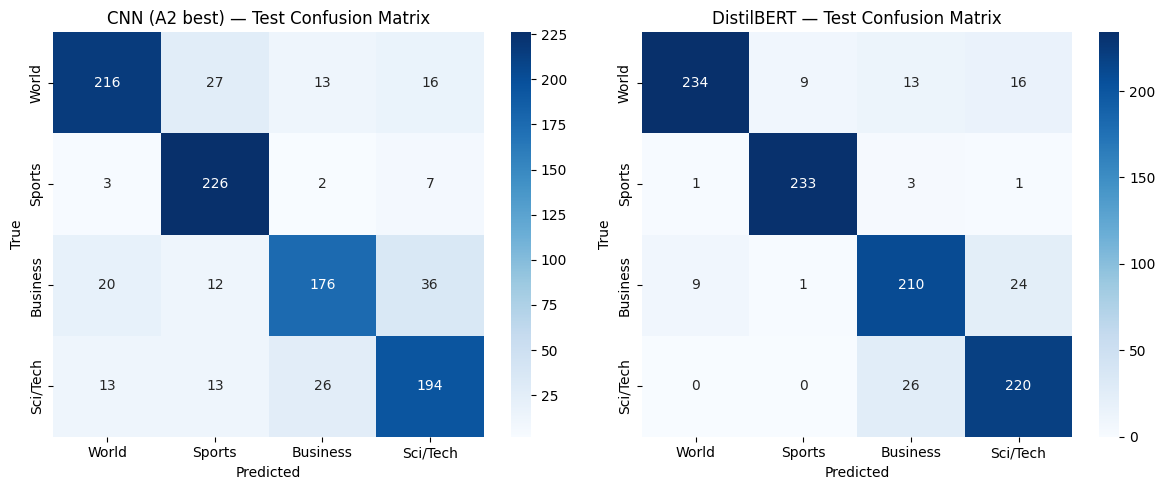


CNN (A2 best):
              precision    recall  f1-score   support

       World       0.86      0.79      0.82       272
      Sports       0.81      0.95      0.88       238
    Business       0.81      0.72      0.76       244
    Sci/Tech       0.77      0.79      0.78       246

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000


DistilBERT:
              precision    recall  f1-score   support

       World       0.96      0.86      0.91       272
      Sports       0.96      0.98      0.97       238
    Business       0.83      0.86      0.85       244
    Sci/Tech       0.84      0.89      0.87       246

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



In [ ]:
# confusion matrices
label_names = [AG_LABELS[i] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, results) in zip(axes, [("CNN (A2 best)", test_cnn),
                                        ("DistilBERT", test_tf)]):
    cm = confusion_matrix(results["y_true"], results["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{name} — Test Confusion Matrix")

fig.tight_layout()
plt.show()

#also print the classification reports
for name, results in [("CNN (A2 best)", test_cnn), ("DistilBERT", test_tf)]:
    print(f"\n{name}:")
    print(classification_report(results["y_true"], results["y_pred"],
                                target_names=label_names))

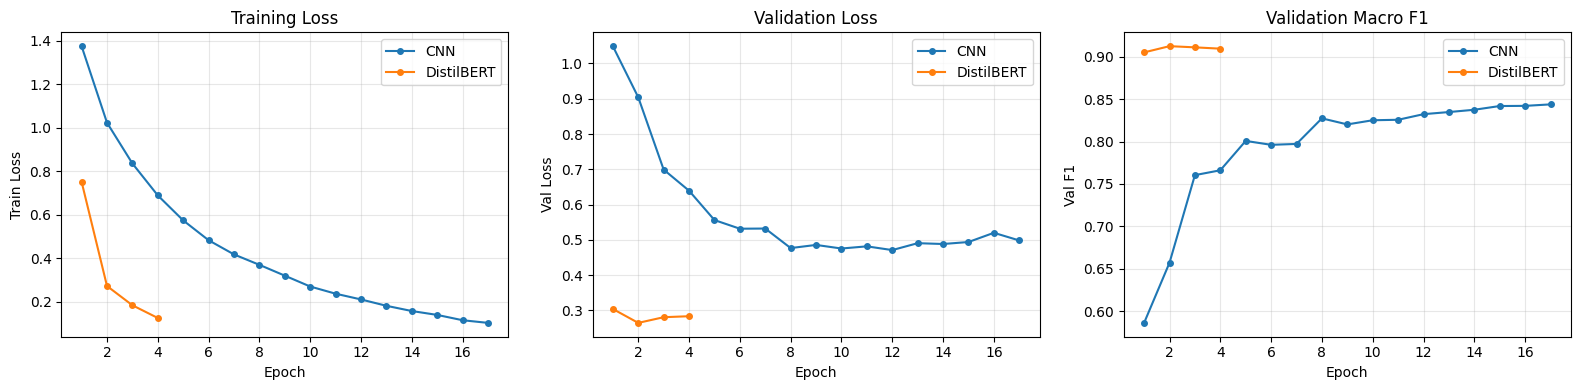

In [ ]:
#compare the learning curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics = [("train_loss", "Training Loss"), ("val_loss", "Validation Loss"), ("val_f1", "Validation Macro F1")]
for ax, (key, title) in zip(axes, metrics):
    for hist, name in [(hist_cnn, "CNN"), (hist_tf, "DistilBERT")]:
        ax.plot([h["epoch"] for h in hist], [h[key] for h in hist],
                marker="o", markersize=4, label=name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(key.replace("_", " ").title())
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [14]:
# check performance for different text lengths
# add a simple word count column to the test set
df_test_eval = df_test.copy()
df_test_eval["word_count"] = df_test_eval["text"].apply(lambda x: len(x.split()))
df_test_eval["true_label"] = df_test_eval["label"] - 1  # shift labels to 0-based indexing

#define the length groups
bins = [(0, 20, "short (≤20)"), (21, 50, "medium (21-50)"),
        (51, 100, "long (51-100)"), (101, 9999, "very long (>100)")]

# get predictions from both models on the full test set
# CNN predictions
cnn_preds = test_cnn["y_pred"]
# DistilBERT predictions
tf_preds = test_tf["y_pred"]

df_test_eval["cnn_pred"] = cnn_preds
df_test_eval["tf_pred"] = tf_preds

print(f"{'Bucket':<20} {'Count':>6} {'CNN Acc':>10} {'CNN F1':>10} {'TF Acc':>10} {'TF F1':>10}")
print("-" * 66)

bucket_results = []
for lo, hi, name in bins:
    mask = (df_test_eval["word_count"] >= lo) & (df_test_eval["word_count"] <= hi)
    subset = df_test_eval[mask]
    if len(subset) == 0:
        continue
    y_true = subset["true_label"].values
    cnn_acc = accuracy_score(y_true, subset["cnn_pred"].values)
    cnn_f1 = f1_score(y_true, subset["cnn_pred"].values, average="macro")
    tf_acc = accuracy_score(y_true, subset["tf_pred"].values)
    tf_f1 = f1_score(y_true, subset["tf_pred"].values, average="macro")
    print(f"{name:<20} {len(subset):>6} {cnn_acc:>10.4f} {cnn_f1:>10.4f} {tf_acc:>10.4f} {tf_f1:>10.4f}")
    bucket_results.append({"bucket": name, "count": len(subset),
                           "cnn_acc": cnn_acc, "cnn_f1": cnn_f1,
                           "tf_acc": tf_acc, "tf_f1": tf_f1})

Bucket                Count    CNN Acc     CNN F1     TF Acc      TF F1
------------------------------------------------------------------
short (≤20)              23     0.5652     0.4571     0.6957     0.5341
medium (21-50)          919     0.8205     0.8190     0.9042     0.9050
long (51-100)            56     0.7679     0.7297     0.8571     0.8329
very long (>100)          2     1.0000     1.0000     1.0000     1.0000


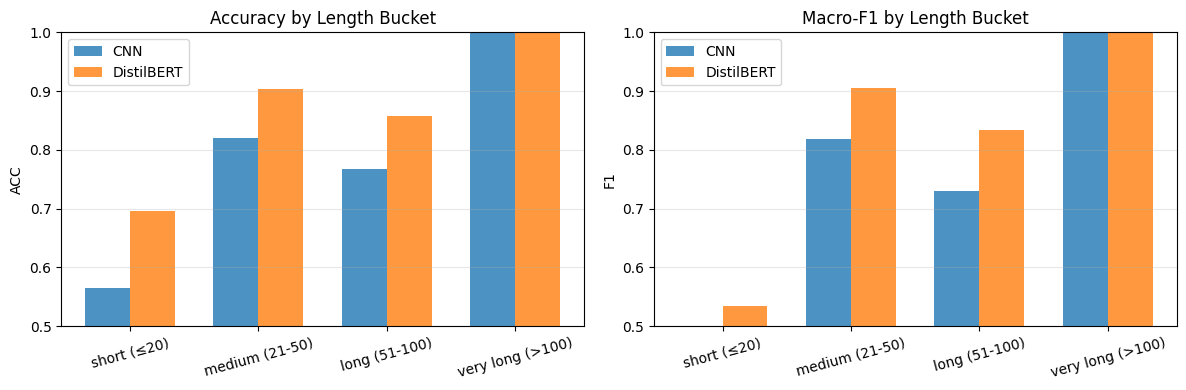

In [15]:
#plot the length-bucket results
bdf = pd.DataFrame(bucket_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = range(len(bdf))
width = 0.35
for ax, metric, title in [(axes[0], "acc", "Accuracy by Length Bucket"),
                           (axes[1], "f1", "Macro-F1 by Length Bucket")]:
    ax.bar([i - width/2 for i in x], bdf[f"cnn_{metric}"], width, label="CNN", alpha=0.8)
    ax.bar([i + width/2 for i in x], bdf[f"tf_{metric}"], width, label="DistilBERT", alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(bdf["bucket"], rotation=15)
    ax.set_ylabel(metric.upper())
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    ax.set_ylim(0.5, 1.0)

fig.tight_layout()
plt.show()

In [16]:
# keyword masking test
CLASS_KEYWORDS = {
    0: ["war", "government", "president", "iraq", "military"],      # world
    1: ["game", "team", "season", "coach", "championship"],         # sports
    2: ["stock", "market", "profit", "company", "shares"],          # business
    3: ["software", "computer", "internet", "technology", "microsoft"],  # sci/tech
}

# flatten all keywords into one list
all_keywords = set()
for kws in CLASS_KEYWORDS.values():
    all_keywords.update(kws)

def mask_keywords(text, keywords, mask_token="[MASK]"):
    """Replace all occurrences of keywords (case-insensitive) with mask_token."""
    for kw in keywords:
        text = re.sub(r'\b' + re.escape(kw) + r'\b', mask_token, text, flags=re.IGNORECASE)
    return text

# make a masked copy of the test set
df_test_masked = df_test.copy()
df_test_masked["text_masked"] = df_test_masked["text"].apply(
    lambda t: mask_keywords(t, all_keywords)
)

# count how many texts were actually changed
n_affected = (df_test_masked["text"] != df_test_masked["text_masked"]).sum()
print(f"Samples with at least one keyword masked: {n_affected} / {len(df_test_masked)}")

Samples with at least one keyword masked: 410 / 1000


In [17]:
# evaluate the CNN on the masked texts
#rebuild the dataloaders with masked text
df_test_masked_cnn = df_test_masked.copy()
df_test_masked_cnn["text"] = df_test_masked_cnn["text_masked"]

masked_test_loader_cnn = DataLoader(
    TextDataset(df_test_masked_cnn, vocab), batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=collate
)
test_cnn_masked = evaluate_cnn(cnn_model, masked_test_loader_cnn)

# evaluate DistilBERT on the masked texts
masked_test_ds_tf = TransformerDataset(df_test_masked_cnn, tokenizer)
masked_test_loader_tf = DataLoader(masked_test_ds_tf, batch_size=TRANSFORMER_BATCH_SIZE, shuffle=False)
test_tf_masked = evaluate_transformer(tf_model, masked_test_loader_tf)

# results after masking
print("Keyword Masking Results:")
print(f"{'Model':<15} {'Original Acc':>14} {'Masked Acc':>12} {'Δ Acc':>8} {'Original F1':>13} {'Masked F1':>11} {'Δ F1':>7}")
print("-" * 80)
for name, orig, masked in [("CNN", test_cnn, test_cnn_masked),
                             ("DistilBERT", test_tf, test_tf_masked)]:
    d_acc = masked["acc"] - orig["acc"]
    d_f1 = masked["f1"] - orig["f1"]
    print(f"{name:<15} {orig['acc']:>14.4f} {masked['acc']:>12.4f} {d_acc:>+8.4f} "
          f"{orig['f1']:>13.4f} {masked['f1']:>11.4f} {d_f1:>+7.4f}")

Keyword Masking Results:
Model             Original Acc   Masked Acc    Δ Acc   Original F1   Masked F1    Δ F1
--------------------------------------------------------------------------------
CNN                     0.8120       0.7990  -0.0130        0.8104      0.7980 -0.0123
DistilBERT              0.8970       0.8990  +0.0020        0.8976      0.8996 +0.0020


In [ ]:
# look at masking impact for each class
# check which classes are affected the most
print("\nPer-class F1 drop after keyword masking:")
print(f"{'Class':<12} {'CNN Orig':>10} {'CNN Mask':>10} {'CNN Δ':>8} {'TF Orig':>10} {'TF Mask':>10} {'TF Δ':>8}")
print("-" * 70)

y_true = test_cnn["y_true"]
for cls_idx in range(NUM_CLASSES):
    cls_mask = y_true == cls_idx
    if cls_mask.sum() == 0:
        continue

# per-class results
from sklearn.metrics import f1_score as f1

orig_cnn_per = f1(y_true, test_cnn["y_pred"], average=None)
mask_cnn_per = f1(y_true, test_cnn_masked["y_pred"], average=None)
orig_tf_per = f1(y_true, test_tf["y_pred"], average=None)
mask_tf_per = f1(y_true, test_tf_masked["y_pred"], average=None)

for i in range(NUM_CLASSES):
    print(f"{AG_LABELS[i]:<12} {orig_cnn_per[i]:>10.4f} {mask_cnn_per[i]:>10.4f} "
          f"{mask_cnn_per[i]-orig_cnn_per[i]:>+8.4f} {orig_tf_per[i]:>10.4f} "
          f"{mask_tf_per[i]:>10.4f} {mask_tf_per[i]-orig_tf_per[i]:>+8.4f}")


Per-class F1 drop after keyword masking:
Class          CNN Orig   CNN Mask    CNN Δ    TF Orig    TF Mask     TF Δ
----------------------------------------------------------------------
World            0.8244     0.8054  -0.0190     0.9070     0.9070  +0.0000
Sports           0.8760     0.8672  -0.0088     0.9688     0.9688  +0.0000
Business         0.7636     0.7601  -0.0035     0.8468     0.8531  +0.0063
Sci/Tech         0.7776     0.7594  -0.0181     0.8679     0.8696  +0.0017


In [19]:
# error analysis for DistilBERT
def get_transformer_errors(model, df, tokenizer, max_items=15):
    model.eval()
    errors = []
    for _, row in df.iterrows():
        encoding = tokenizer(
            str(row["text"]),
            max_length=TRANSFORMER_MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        input_ids = encoding["input_ids"].to(device)
        attention_mask = encoding["attention_mask"].to(device)
        y = int(row["label"]) - 1

        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            pred = int(logits.argmax(dim=1).item())
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

        if pred != y:
            snippet = row["text"].replace("\n", " ")
            snippet = snippet[:300] + ("..." if len(snippet) > 300 else "")
            errors.append({
                "true": AG_LABELS[y], "pred": AG_LABELS[pred],
                "true_idx": y, "pred_idx": pred,
                "confidence": probs[pred],
                "text": snippet
            })
        if len(errors) >= max_items:
            break
    return errors

tf_errors = get_transformer_errors(tf_model, df_test, tokenizer, max_items=15)

print(f"Showing {len(tf_errors)} DistilBERT errors:\n")
for i, err in enumerate(tf_errors):
    print(f"Error {i+1}")
    print(f"  True: {err['true']}  →  Predicted: {err['pred']}  (confidence: {err['confidence']:.2%})")
    print(f"  Text: {err['text']}")
    print()

Showing 15 DistilBERT errors:

Error 1
  True: Business  →  Predicted: Sci/Tech  (confidence: 95.04%)
  Text: FaceTime, IMlogic Back Live Communications Server 2005 Hard on the heels of Microsoft announcing that it #39;s taken Live Communications Server 2005 gold, instant messaging management software vendors IMlogic and FaceTime on Tuesday both touted their support for the communication product.

Error 2
  True: Business  →  Predicted: Sci/Tech  (confidence: 74.41%)
  Text: Telephone Tag (Forbes.com) Forbes.com - ARRIS GROUP (5, ARRS) saw its market cap unjustifiably halved recently when Comcast, a huge customer (24 of Arris' sales), hinted it might buy next-generation technology from Cisco Systems. Arris supplies the technical guts that cable companies use to provide ...

Error 3
  True: Business  →  Predicted: Sci/Tech  (confidence: 73.06%)
  Text: Oracle v. Peoplesoft: the joke is on... Opinion I thought it was a joke when Oracle first announced that it was going to try to buy Peop

In [20]:
# summarize the main error patterns
# count the most common confusion patterns
from collections import Counter as Ctr

error_patterns = Ctr()
for err in tf_errors:
    error_patterns[(err["true"], err["pred"])] += 1

print("Most common error patterns (DistilBERT):")
for (true, pred), count in error_patterns.most_common():
    print(f"  {true} → {pred}: {count} errors")

Most common error patterns (DistilBERT):
  Business → Sci/Tech: 6 errors
  Sci/Tech → Business: 4 errors
  World → Business: 2 errors
  World → Sci/Tech: 2 errors
  Business → Sports: 1 errors


In [21]:
# CNN error analysis for comparison
def get_cnn_errors(model, df, max_items=15):
    model.eval()
    errors = []
    for _, row in df.iterrows():
        tokens = tokenize(str(row["text"]))
        ids = numericalize(tokens, vocab)[:MAX_LEN] or [vocab[UNK]]
        x = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
        lengths = torch.tensor([len(ids)], dtype=torch.long).to(device)
        y = int(row["label"]) - 1

        with torch.no_grad():
            logits = model(x, lengths)
            pred = int(logits.argmax(dim=1).item())

        if pred != y:
            snippet = row["text"].replace("\n", " ")
            snippet = snippet[:300] + ("..." if len(snippet) > 300 else "")
            errors.append({"true": AG_LABELS[y], "pred": AG_LABELS[pred], "text": snippet})
        if len(errors) >= max_items:
            break
    return errors

cnn_errors = get_cnn_errors(cnn_model, df_test, max_items=15)

print(f"Showing {len(cnn_errors)} CNN errors:\n")
for i, err in enumerate(cnn_errors):
    print(f"Error {i+1}")
    print(f"  True: {err['true']}  →  Predicted: {err['pred']}")
    print(f"  Text: {err['text']}")
    print()

Showing 15 CNN errors:

Error 1
  True: Business  →  Predicted: Sci/Tech
  Text: FaceTime, IMlogic Back Live Communications Server 2005 Hard on the heels of Microsoft announcing that it #39;s taken Live Communications Server 2005 gold, instant messaging management software vendors IMlogic and FaceTime on Tuesday both touted their support for the communication product.

Error 2
  True: Business  →  Predicted: Sci/Tech
  Text: Telephone Tag (Forbes.com) Forbes.com - ARRIS GROUP (5, ARRS) saw its market cap unjustifiably halved recently when Comcast, a huge customer (24 of Arris' sales), hinted it might buy next-generation technology from Cisco Systems. Arris supplies the technical guts that cable companies use to provide ...

Error 3
  True: Business  →  Predicted: Sports
  Text: Oracle v. Peoplesoft: the joke is on... Opinion I thought it was a joke when Oracle first announced that it was going to try to buy PeopleSoft; or, at best, a spoiling tactic over PeopleSoft #39;s acquisition of